# 460 — Functional-role matching (concatenated, conjunction)

The **condition-structured** path. Each contact is the three conditions stitched in time,
`[audio | picture | reading]`. We **discretize** to a clustering-exact −1/0/+1 map (the same
segmentation 02 uses — `CLUSTERING_SEG_KWARGS`, no score gate) and assign a
**functional role** only if the contact expresses **every** box of that role's conjunction
template (strict AND) — a box expresses its sign via the clustering **proportion gate** on the
−1/+1 cells. Roles live in `functions/roi_config_concatenated.py` (auditory / visual / motor /
multimodal — **draft, edit them**).

- **Auditory** = HGA in the audio **stimulus** + the **response** of all three (hears stimulus +
  hears own voice ×3). **Motor** = HGA in all three responses. **Visual** = HGA in the picture &
  reading stimuli. The discriminator is the *stimulus* boxes (response is shared motor/feedback —
  only **anatomy** separates those, which is what the POOL map shows).
- One sample per contact; **only contacts with all three conditions** enter.
- `role` = the **most specific** matching template (most boxes); `roles_matched` lists all.

> Discretization needs blob resolution, so `USE_DS=False` (full 129×300) is the faithful baseline;
> `USE_DS=True` downsamples the painted map (faster, coarser).


In [1]:
import os, sys
from pathlib import Path
import numpy as np, pandas as pd
from IPython.display import display, Markdown, Image
sys.path.insert(0, str(Path('..').resolve()))
from functions import lf_pool as P

INPUT_DIR = Path(r'\\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_LoraFanda\01_FBM_Analysis\outputs\04_ersp_LM_RAWONLY')
if not INPUT_DIR.exists():
    INPUT_DIR = Path('../01_FBM_Analysis/outputs/04_ersp_LM_RAWONLY').resolve()

print('INPUT_DIR :', INPUT_DIR, '| exists:', INPUT_DIR.exists())
print('OUTPUTS   :', P.OUTPUTS_ROOT)
print('COORDS    :', P.COORDS_DIR, '| exists:', P.COORDS_DIR.exists())
print('conditions:', P.CONDITIONS, '| zones:', P.DEFAULT_ZONES)
print('feature sets:', P.FEATURE_SETS, '| window shapes:', P.WINDOW_SHAPES)


INPUT_DIR : \\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_LoraFanda\01_FBM_Analysis\outputs\04_ersp_LM_RAWONLY | exists: True
OUTPUTS   : \\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_LoraFanda\04_FBM_Pooling\outputs\pooling
COORDS    : \\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_LoraFanda\02_FBM_Clustering\outputs\250_recon\fsaverage\coords | exists: True
conditions: ('audio', 'picture', 'reading') | zones: ('perception', 'pre_articulation', 'audio')
feature sets: ('hg', 'bands15') | window shapes: ('boxcar', 'gaussian')


In [2]:
# ---- knobs ----
USE_DS    = True                    # False: full-res discretized baseline (recommended) · True: ds
GRID      = 'ds' if USE_DS else 'full'
print('grid:', GRID, '| roles:', [r['role'] for r in P.ROLE_PARAMS[GRID]['roles']])


grid: ds | roles: ['auditory', 'auditory_v2', 'visual_picture', 'visual_reading', 'picture_stim', 'pic_stim', 'lexical_semantic', 'heteromodal_convergence', 'maintenance', 'premotor planning', 'phonological_encoding', 'motor', 'motor_v2', 'auditory_feedback', 'deactivation', 'NN', 'tag_hga_activation', 'tag_beta_erd', 'tag_low_f_erd', 'tag_theta_tracking', 'ultra_hfa', 'stimulus_active', 'response_active']


## 1 — Load dataset


In [3]:
df_meta, X_full = P.prepare_pooling_dataset(INPUT_DIR)
print('loaded:', len(df_meta), 'rows |', df_meta['condition'].value_counts().to_dict())


[lf_dataset cache hit] \\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_LoraFanda\04_FBM_Pooling\outputs\_dataset\pooling\_raw_ungated
  8841 samples · X_3d.shape=(8841, 129, 300)
[lf_pool] 8841 samples, 8841 with a contact key, X_3d=(8841, 129, 300)
loaded: 8841 rows | {'picture': 3013, 'audio': 2972, 'reading': 2856}


## 2 — Concatenate raw dB ERSP (one map per all-3-condition contact)


In [4]:
X_input = P.downsample_dataset(X_full) if USE_DS else X_full
df_contacts, X_raw = P.build_concat_raw(df_meta, X_input)
print('contacts (DS):', len(df_contacts), '| X_raw:', X_raw.shape)

# Full-res concat for smoother HGA timeseries plots (300 time bins/condition vs 30)
df_contacts_full, X_raw_full = P.build_concat_raw(df_meta, X_full)
print('contacts (full):', len(df_contacts_full), '| X_raw_full:', X_raw_full.shape)
df_contacts.head()

[build_X_3d_downsampled] 8841 samples · 15 freq bins · 30 time bins · flat dim = 450
[lf_pool] concat-raw: 2856 contacts, all 3 conditions · X_raw=(2856, 15, 90)
contacts (DS): 2856 | X_raw: (2856, 15, 90)
[lf_pool] concat-raw: 2856 contacts, all 3 conditions · X_raw=(2856, 129, 900)
contacts (full): 2856 | X_raw_full: (2856, 129, 900)


,patient_id,contact_norm,electrode
0,EL030,AL10,A_L10
1,EL030,AL11,A_L11
2,EL030,AL12,A_L12
3,EL030,AL13,A_L13
4,EL030,AL14,A_L14


## 3 — Raw-dB role matching (mirrors poolv2 Apply button exactly)
Per-role `thr` and `frac` come from `roi_config_concatenated.py`.
`role` = most-specific match; `roles_matched` lists all.


[lf_pool] roles_raw run -> \\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_LoraFanda\04_FBM_Pooling\outputs\pooling\roles_raw\ds\runs\20260719_125333
[lf_pool] role table (raw dB): (2856, 7)


,role,n_matched,n_primary
0,tag_low_f_erd,598,274
1,tag_beta_erd,391,301
2,tag_theta_tracking,263,180
3,tag_hga_activation,151,70
4,auditory,149,133
5,ultra_hfa,128,70
6,response_active,116,0
7,stimulus_active,55,0
8,premotor planning,52,49
9,NN,30,27


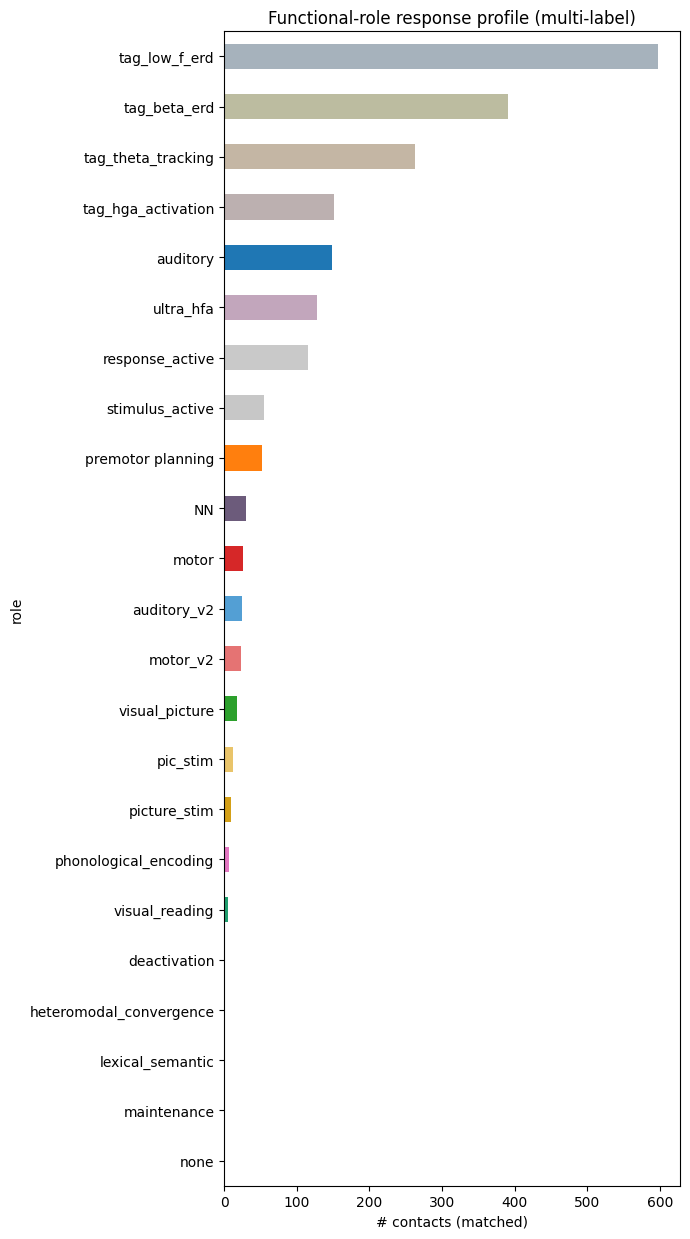

In [5]:
import matplotlib.pyplot as plt
df_role = P.build_role_table_raw(df_contacts, X_raw, grid=GRID)
counts = P.role_counts(df_role)
display(counts)
# role_counts is multi-label: n_matched = contacts where the role is in roles_matched
# (a contact counts toward every role it shows); n_primary = most-specific winner.
ax = counts.set_index('role')['n_matched'].plot.barh(figsize=(7, 0.5 * len(counts) + 1),
        color=[P.role_colors(GRID).get(r, '#888') for r in counts['role']])
ax.set_xlabel('# contacts (matched)'); ax.set_title('Functional-role response profile (multi-label)')
ax.invert_yaxis(); plt.tight_layout(); plt.show()


## 3b — Role co-occurrence (multi-label overlap)
How often each pair of roles is matched by the **same** contact (via `roles_matched`).
The **diagonal** = total contacts matching that role; **off-diagonal** = the size of each
pairwise intersection — the "Venn" view across all roles at once (e.g. how many contacts
are *both* `auditory` and `auditory_suppression`).


In [6]:
df_role

,patient_id,contact_norm,electrode,grid,role,roles_matched,n_roles
0,EL030,AL10,A_L10,ds,none,,0
1,EL030,AL11,A_L11,ds,none,,0
2,EL030,AL12,A_L12,ds,tag_hga_activation,tag_hga_activation;response_active,2
3,EL030,AL13,A_L13,ds,motor,motor;tag_hga_activation;ultra_hfa;response_ac...,4
4,EL030,AL14,A_L14,ds,motor,motor;tag_hga_activation;ultra_hfa;response_ac...,4
...,...,...,...,...,...,...,...
2851,PAT_6854,X2M4,X2m4,ds,tag_low_f_erd,tag_low_f_erd,1
2852,PAT_6854,X2M5,X2m5,ds,tag_low_f_erd,tag_low_f_erd,1
2853,PAT_6854,X2M6,X2m6,ds,tag_low_f_erd,tag_low_f_erd,1
2854,PAT_6854,X2M7,X2m7,ds,tag_low_f_erd,tag_low_f_erd,1


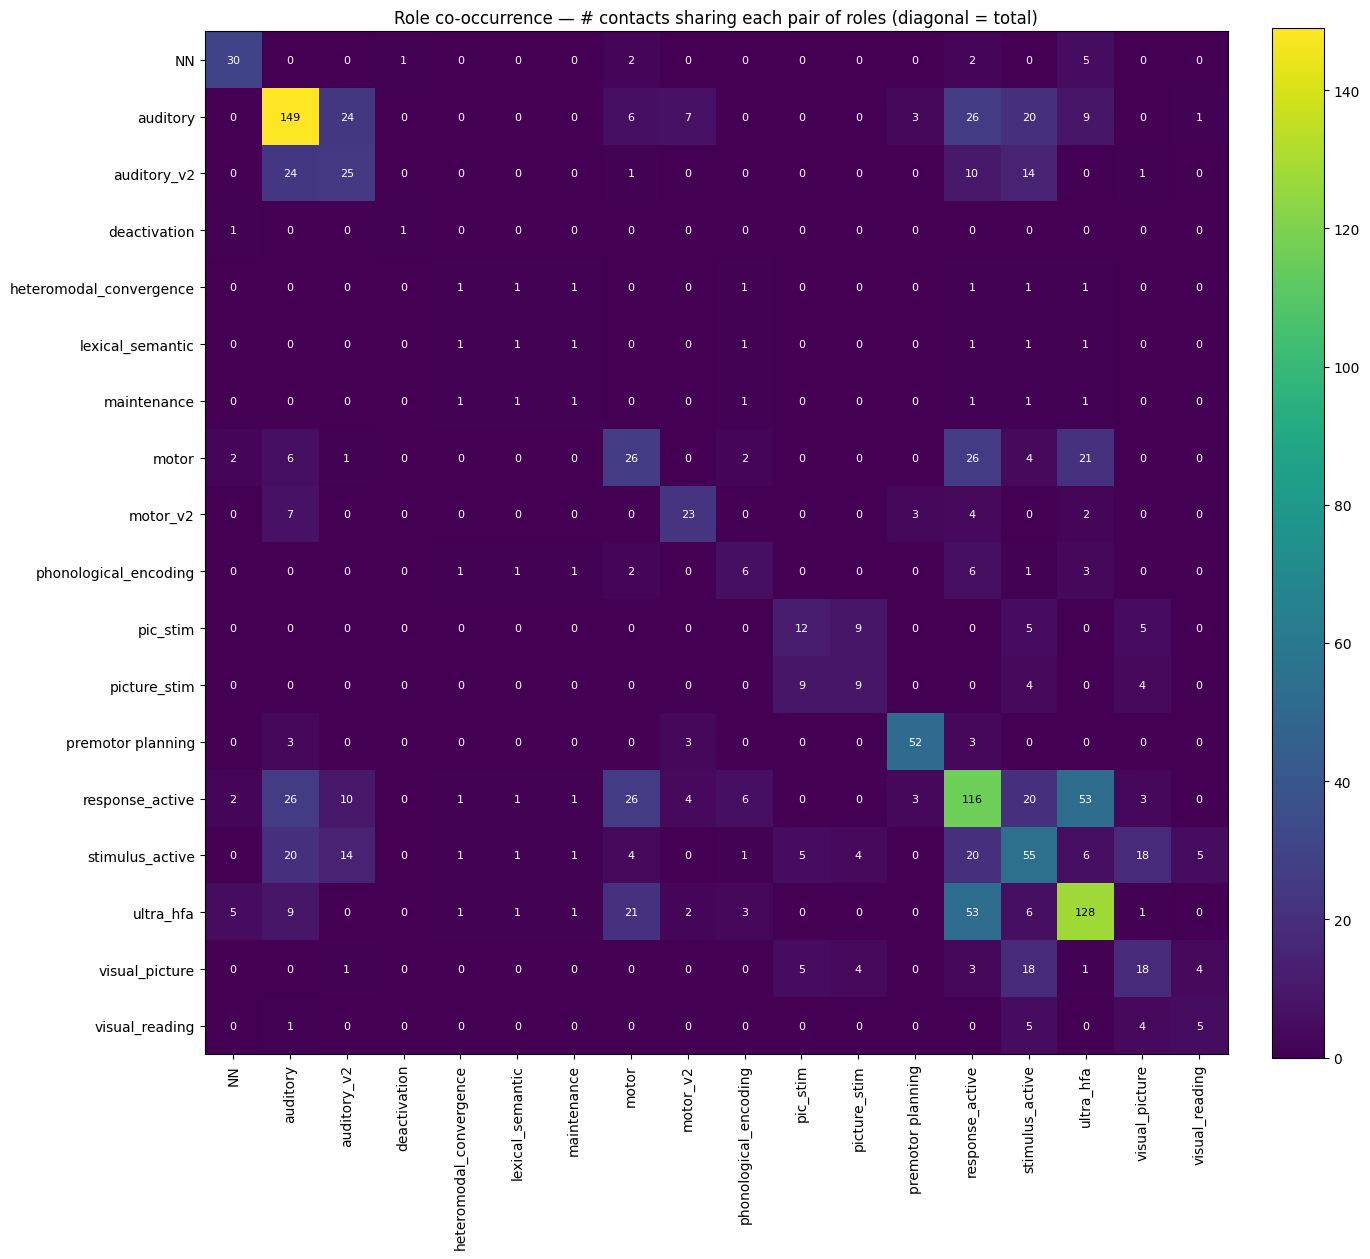

In [7]:
import numpy as np, matplotlib.pyplot as plt
M = P.role_membership(df_role)                       # one row/contact, bool col per matched role
role_cols = [c for c in M.columns if c not in ('patient_id', 'contact_norm')
             and not c.startswith('tag_')]
B = M[role_cols].to_numpy().astype(int)
C = B.T @ B                                          # co-occurrence counts; diagonal = n_matched
fig, ax = plt.subplots(figsize=(0.6 * len(role_cols) + 3, 0.6 * len(role_cols) + 3))
im = ax.imshow(C, cmap='viridis')
ax.set_xticks(range(len(role_cols))); ax.set_xticklabels(role_cols, rotation=90)
ax.set_yticks(range(len(role_cols))); ax.set_yticklabels(role_cols)
vmax = int(C.max()) if C.size else 1
for i in range(len(role_cols)):
    for j in range(len(role_cols)):
        ax.text(j, i, int(C[i, j]), ha='center', va='center', fontsize=8,
                color='white' if C[i, j] < vmax * 0.6 else 'black')
ax.set_title('Role co-occurrence — # contacts sharing each pair of roles (diagonal = total)')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout(); plt.show()

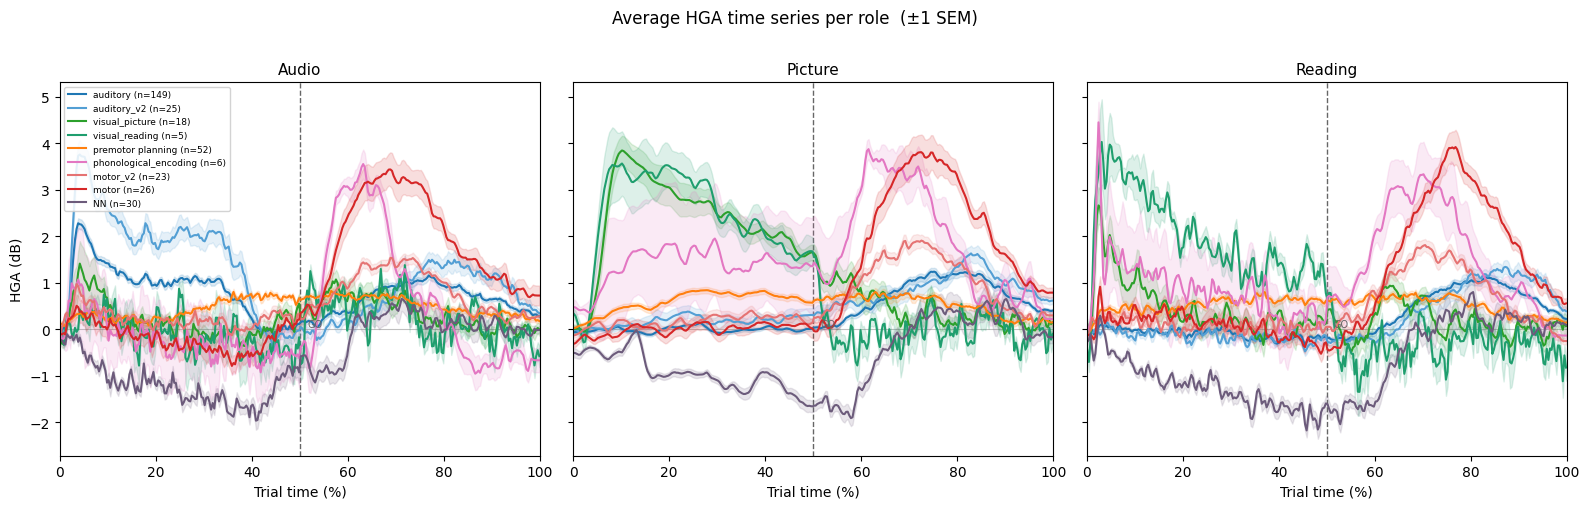

Updated: role_info.json
Updated: role_info.json

Onset order per condition:

  AUDIO:
    phonological_encoding                1.8%
    auditory                             2.2%
    auditory_v2                          2.2%
    visual_picture                       2.5%
    motor_v2                             2.8%
    motor                                3.5%
    NN                                   4.8%
    visual_reading                       9.2%
    premotor planning                    31.5%
    auditory_feedback                    100.0%

  PICTURE:
    NN                                   0.2%
    visual_reading                       3.8%
    visual_picture                       4.5%
    phonological_encoding                4.5%
    premotor planning                    12.2%
    auditory_v2                          54.2%
    motor_v2                             54.2%
    motor                                56.2%
    auditory                             62.8%
    auditory_feedbac

In [8]:
import json, importlib
importlib.reload(P)   # reload lf_pool in case you edited it

POOL_OUT       = P.OUTPUTS_ROOT / 'pool_web'
POOL_OUT_GAUSS = P.OUTPUTS_ROOT / 'pool_web_gaussian'

# Layer-1 functional roles to plot — edit this list to add/remove roles
PLOT_ROLES = [
    "auditory", "auditory_v2",
    "visual_picture", "visual_reading", # "pic_stim",
    # "lexical_semantic", "heteromodal_convergence", "maintenance",
    "premotor planning", "phonological_encoding",
    "motor_v2", "auditory_feedback",
    "motor", "NN",
]

# role_info.json supplies colors + metadata for the legend
with open(POOL_OUT / "role_info.json", encoding="utf-8") as f:
    role_info = json.load(f)

# Plot HGA time series using full-res ERSP (300 time bins/condition) for smooth curves.
# Role assignments (df_role) still come from DS matching; keys link them to df_contacts_full.
fig, onset_dict = P.plot_role_hga_timeseries(
    df_contacts_full, X_raw_full, df_role,
    role_info, roles=PLOT_ROLES, grid='full', onset_thr_db=0.5,
    out_png=POOL_OUT / "hga_timeseries.png")
plt.show()

# Patch onset_t_pct (earliest across conditions) into both role_info.json files
for path in [POOL_OUT / "role_info.json", POOL_OUT_GAUSS / "role_info.json"]:
    with open(path, encoding="utf-8") as f:
        ri = json.load(f)
    for rname, cond_onsets in onset_dict.items():
        if rname in ri:
            ri[rname]["onset_t_pct"] = round(min(cond_onsets.values()), 1)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(ri, f, indent=1)
    print(f"Updated: {path.name}")

print("\nOnset order per condition:")
for cond in ["audio", "picture", "reading"]:
    print(f"\n  {cond.upper()}:")
    ranked = sorted(onset_dict.items(), key=lambda x: x[1][cond])
    for role, onsets in ranked:
        print(f"    {role:35s}  {onsets[cond]:.1f}%")

C:\Users\artoni\AppData\Local\Temp\ipykernel_33312\670704658.py:47: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


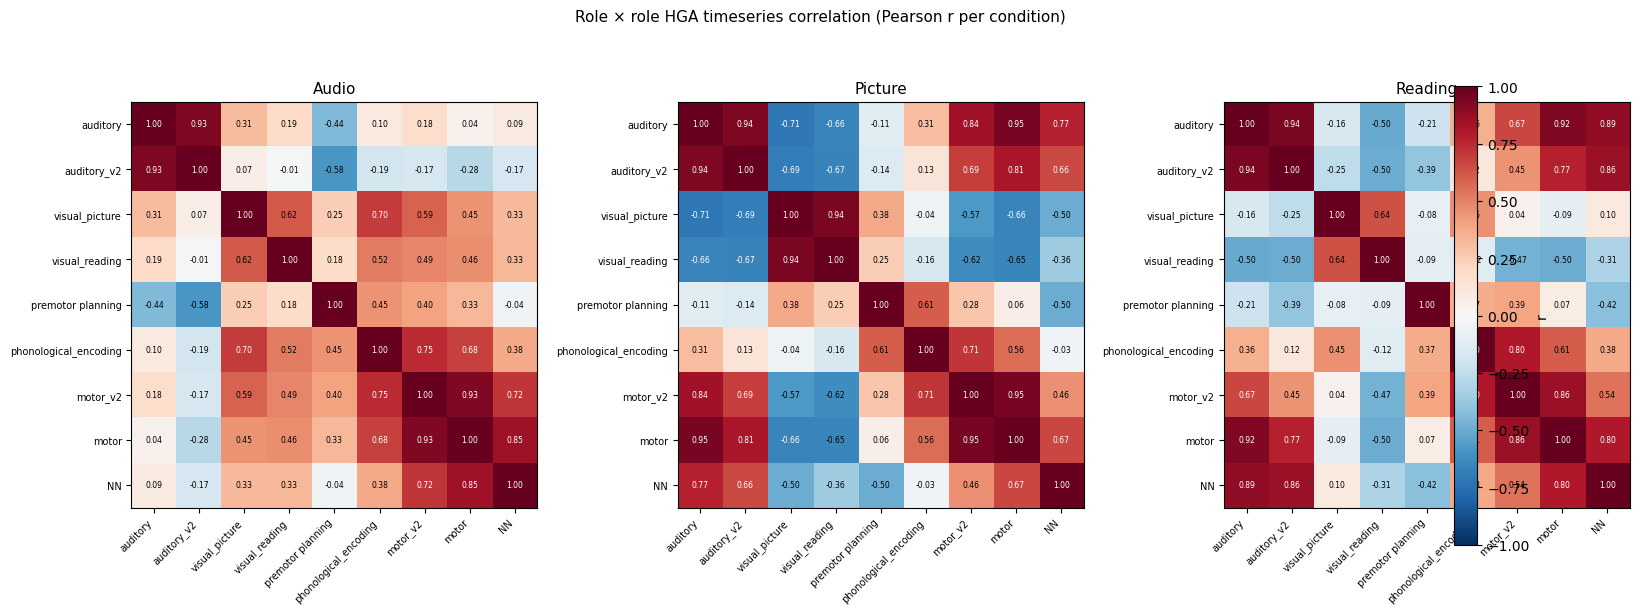

In [9]:
## 3c — Role × role HGA timeseries correlation (per condition)
# Pearson r between each pair of roles' mean HGA curves.
# High r = similar temporal profile; low/negative = distinct timing.
from scipy.stats import pearsonr

_nf  = X_raw_full.shape[1]
_hz  = P.FMAX_HZ / _nf
_hga_rows = np.array([i for i in range(_nf) if i * _hz < 150.0 and (i + 1) * _hz > 70.0])
_hga_all  = X_raw_full[:, _hga_rows, :].mean(axis=1)         # (n_contacts, 900)

_p, _c = 'patient_id', 'contact_norm'
_key2idx = {(r[_p], r[_c]): i for i, r in df_contacts_full.iterrows()}
_msets   = {(r[_p], r[_c]): set(str(r.get('roles_matched','') or '').split(';')) - {''}
            for _, r in df_role.iterrows()}

CONDS_LIST = ['audio', 'picture', 'reading']
nt = 300

# Build per-role mean HGA per condition
role_hga = {}
for rname in PLOT_ROLES:
    idxs = [_key2idx[k] for k, ms in _msets.items() if rname in ms and k in _key2idx]
    if not idxs:
        continue
    mat = _hga_all[np.array(idxs)]
    role_hga[rname] = {cond: mat[:, i*nt:(i+1)*nt].mean(0) for i, cond in enumerate(CONDS_LIST)}

valid_roles = list(role_hga.keys())
n = len(valid_roles)
fig, axes = plt.subplots(1, 3, figsize=(5.5*3, max(4.5, 0.55*n+1)))
colors_map = {r: role_info.get(r, {}).get('color', '#888') for r in valid_roles}

for ax, cond in zip(axes, CONDS_LIST):
    R = np.array([[pearsonr(role_hga[r1][cond], role_hga[r2][cond])[0]
                   for r2 in valid_roles] for r1 in valid_roles])
    im = ax.imshow(R, cmap='RdBu_r', vmin=-1, vmax=1)
    ax.set_xticks(range(n)); ax.set_xticklabels(valid_roles, rotation=45, ha='right', fontsize=7)
    ax.set_yticks(range(n)); ax.set_yticklabels(valid_roles, fontsize=7)
    for i in range(n):
        for j in range(n):
            ax.text(j, i, f'{R[i,j]:.2f}', ha='center', va='center', fontsize=5.5,
                    color='white' if abs(R[i,j]) > 0.65 else 'black')
    ax.set_title(f'{cond.capitalize()}', fontsize=11)

fig.suptitle('Role × role HGA timeseries correlation (Pearson r per condition)', fontsize=11, y=1.01)
fig.colorbar(im, ax=axes.tolist(), fraction=0.02, pad=0.03, label='r')
plt.tight_layout(); plt.show()

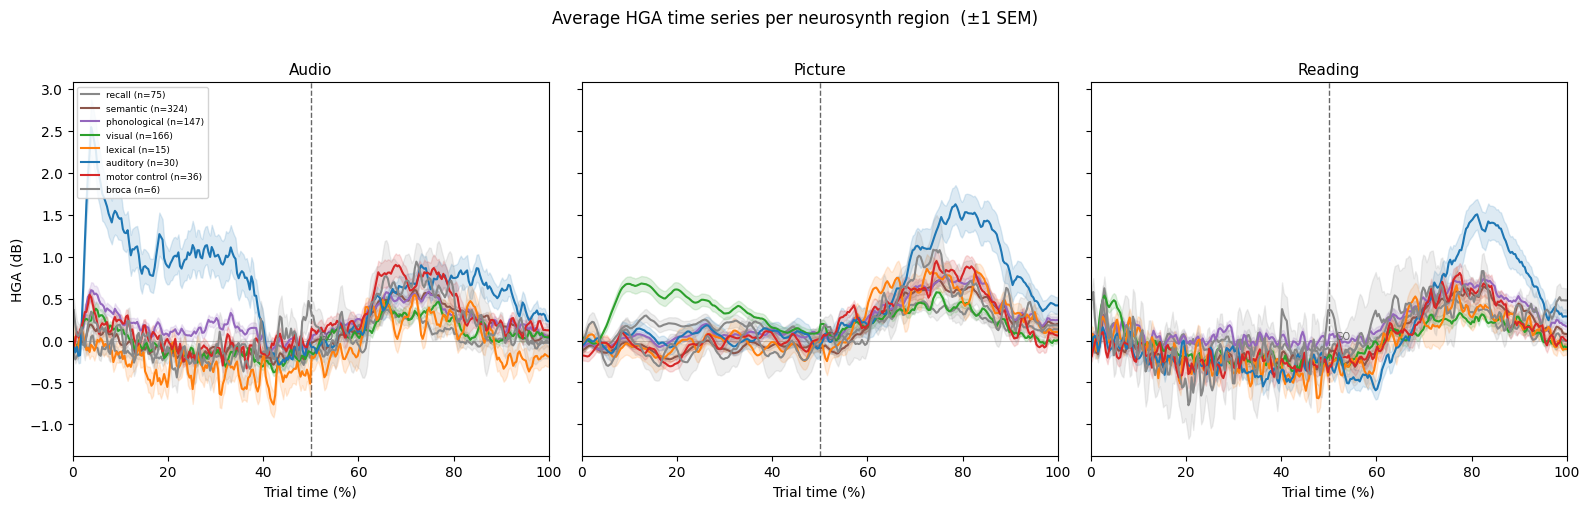

Region onset order per condition:

  AUDIO:
    auditory                        2.2%
    phonological                    2.8%
    motor control                   3.2%
    lexical                         15.5%
    broca                           21.8%
    semantic                        63.8%
    visual                          65.5%
    recall                          100.0%

  PICTURE:
    visual                          6.8%
    motor control                   57.2%
    lexical                         60.2%
    phonological                    63.2%
    broca                           63.2%
    auditory                        64.8%
    semantic                        65.8%
    recall                          66.2%

  READING:
    broca                           0.2%
    visual                          2.2%
    recall                          2.5%
    lexical                         14.2%
    auditory                        15.5%
    motor control                   18.5%
    phonologic

In [10]:
import json
importlib.reload(P)

NS_OUT = P.OUTPUTS_ROOT / 'neurosynth'

ns_labels = pd.read_csv(NS_OUT / 'neurosynth_labels.csv')
with open(NS_OUT / 'neurosynth_info.json', encoding='utf-8') as f:
    region_info = json.load(f)

# Full-res ERSP for smoother time axis (300 bins/condition)
fig, ns_onset_dict = P.plot_region_hga_timeseries(
    df_contacts_full, X_raw_full, ns_labels,
    region_info, grid='full', onset_thr_db=0.4,
    out_png=NS_OUT / 'hga_timeseries.png')
plt.show()

print("Region onset order per condition:")
for cond in ["audio", "picture", "reading"]:
    print(f"\n  {cond.upper()}:")
    ranked = sorted(ns_onset_dict.items(), key=lambda x: x[1][cond])
    for region, onsets in ranked:
        print(f"    {region:30s}  {onsets[cond]:.1f}%")

C:\Users\artoni\AppData\Local\Temp\ipykernel_33312\426528264.py:41: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


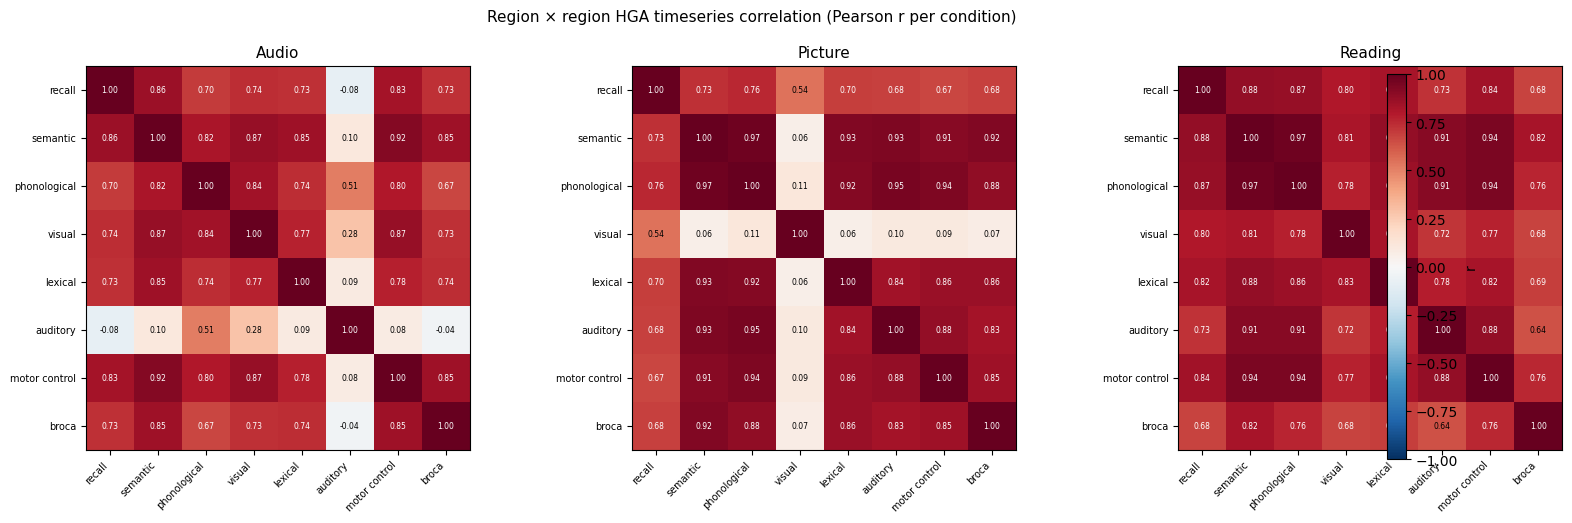

In [11]:
## 3d — Neurosynth region × region HGA timeseries correlation (per condition)
# Reuses _hga_all, _key2idx, CONDS_LIST, nt from cell 3c above.

_ns_valid = ns_labels[ns_labels['neurosynth_primary'].notna() & (ns_labels['neurosynth_primary'] != '')]
_np_col   = 'patient_id' if 'patient_id' in ns_labels.columns else 'patient'
_nc_col   = 'contact_norm' if 'contact_norm' in ns_labels.columns else 'contact'
region_list_corr = [r for r in _ns_valid['neurosynth_primary'].unique() if r in region_info]

# Per-region mean HGA per condition
region_hga = {}
for rname in region_list_corr:
    rows_r = _ns_valid[_ns_valid['neurosynth_primary'] == rname]
    mats = {cond: [] for cond in CONDS_LIST}
    for _, row in rows_r.iterrows():
        idx = _key2idx.get((row[_np_col], row[_nc_col]))
        if idx is None:
            continue
        for i, cond in enumerate(CONDS_LIST):
            mats[cond].append(_hga_all[idx, i*nt:(i+1)*nt])
    if all(mats[c] for c in CONDS_LIST):
        region_hga[rname] = {c: np.stack(mats[c]).mean(0) for c in CONDS_LIST}

valid_regions = list(region_hga.keys())
nr = len(valid_regions)
fig, axes = plt.subplots(1, 3, figsize=(5.5*3, max(4.5, 0.5*nr+1)))

for ax, cond in zip(axes, CONDS_LIST):
    R = np.array([[pearsonr(region_hga[r1][cond], region_hga[r2][cond])[0]
                   for r2 in valid_regions] for r1 in valid_regions])
    im = ax.imshow(R, cmap='RdBu_r', vmin=-1, vmax=1)
    ax.set_xticks(range(nr)); ax.set_xticklabels(valid_regions, rotation=45, ha='right', fontsize=7)
    ax.set_yticks(range(nr)); ax.set_yticklabels(valid_regions, fontsize=7)
    for i in range(nr):
        for j in range(nr):
            ax.text(j, i, f'{R[i,j]:.2f}', ha='center', va='center', fontsize=5.5,
                    color='white' if abs(R[i,j]) > 0.65 else 'black')
    ax.set_title(f'{cond.capitalize()}', fontsize=11)

fig.suptitle('Region × region HGA timeseries correlation (Pearson r per condition)', fontsize=11, y=1.01)
fig.colorbar(im, ax=axes.tolist(), fraction=0.02, pad=0.03, label='r')
plt.tight_layout(); plt.show()

## 4 — Export for the POOL web page
Writes `contacts_pool.csv` (xyz + role + colour) + `pool_index.json` to the **stable**
`outputs/pooling/pool_web/` path that `web/pool.html` (Niivue, in your `lorafanda.github.io`
repo) reads via raw-GitHub. Reuses the MOBA fsaverage meshes. **Commit + push** that folder so
the page can fetch it.


In [12]:
## 3e — Per-contact HGA strength (for gradient electrode coloring on fsaverage)
# Strength = peak HGA dB (70-150 Hz) across the full timeseries, normalized
# within each layer-1 role so the strongest contact = 1.0, weakest = 0.0.
# export_pool_web will lerp electrode color from white (0) to role color (1).

# Recompute _hga_all / _key2idx if not already in scope from cell 3c.
if '_hga_all' not in dir():
    _nf  = X_raw_full.shape[1]
    _hz  = P.FMAX_HZ / _nf
    _hga_rows = np.array([i for i in range(_nf) if i * _hz < 150.0 and (i + 1) * _hz > 70.0])
    _hga_all  = X_raw_full[:, _hga_rows, :].mean(axis=1)
    _key2idx  = {(r['patient_id'], r['contact_norm']): i for i, r in df_contacts_full.iterrows()}

_hga_peak = _hga_all.max(axis=1)                              # (n_contacts,) peak per contact
_key_to_peak = {k: _hga_peak[i] for k, i in _key2idx.items()}
df_role['_hga_pk'] = df_role.apply(
    lambda r: _key_to_peak.get((r['patient_id'], r['contact_norm']), np.nan), axis=1)

layer1_roles = {r['role'] for r in P.ROLE_PARAMS[GRID]['roles'] if r.get('layer', 1) == 1}
df_role['hga_strength'] = np.nan
for rname in layer1_roles:
    mask = df_role['role'] == rname
    if not mask.any():
        continue
    vals = df_role.loc[mask, '_hga_pk']
    mn, mx = vals.min(), vals.max()
    df_role.loc[mask, 'hga_strength'] = (
        ((vals - mn) / (mx - mn)).clip(0, 1) if mx > mn else 1.0)
df_role.drop(columns=['_hga_pk'], inplace=True)

n_with = df_role['hga_strength'].notna().sum()
print(f'hga_strength assigned to {n_with} contacts across {len(layer1_roles)} layer-1 roles')
print(df_role.groupby('role')['hga_strength'].describe().loc[
    df_role.groupby('role')['hga_strength'].mean().dropna().index,
    ['count', 'mean', 'min', 'max']].round(2).to_string())

hga_strength assigned to 288 contacts across 16 layer-1 roles
                       count  mean  min  max
role                                        
NN                      27.0  0.44  0.0  1.0
auditory               133.0  0.26  0.0  1.0
auditory_v2              1.0  1.00  1.0  1.0
deactivation             1.0  1.00  1.0  1.0
lexical_semantic         1.0  1.00  1.0  1.0
motor                   26.0  0.22  0.0  1.0
motor_v2                23.0  0.29  0.0  1.0
phonological_encoding    3.0  0.53  0.0  1.0
pic_stim                 2.0  0.50  0.0  1.0
picture_stim             5.0  0.35  0.0  1.0
premotor planning       49.0  0.30  0.0  1.0
visual_picture          17.0  0.43  0.0  1.0


In [13]:
coords = P.load_coords()
# df_meta carries each contact's ERSP file_path per condition -> pool_samples.json
# so pool.html can show the selected pool's ERSPs (samples strip).
web = P.export_pool_web(df_role, coords, P.OUTPUTS_ROOT / 'pool_web', grid=GRID, df_meta=df_meta)
print('POOL web data ->', web)
# per-role info cards (description + box/gaussian template on a representative ERSP) for the web info panel
P.export_role_info(INPUT_DIR, df_role, P.OUTPUTS_ROOT / 'pool_web', grid=GRID)
# downsampled raw-ERSP cube for the poolv2 interactive role designer (fraction-above-threshold, client-side)
P.export_pool_cube(INPUT_DIR, df_contacts, P.OUTPUTS_ROOT / 'pool_cube')


[lf_pool] POOL samples -> pool_samples.json  (2644 contacts)
[lf_pool] POOL web export -> \\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_LoraFanda\04_FBM_Pooling\outputs\pooling\pool_web  (2644 contacts)
POOL web data -> \\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_LoraFanda\04_FBM_Pooling\outputs\pooling\pool_web
[lf_pool] role_info -> \\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_LoraFanda\04_FBM_Pooling\outputs\pooling\pool_web\role_info.json  (23 roles, 17 cards)
[lf_pool] pool cube -> \\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_LoraFanda\04_FBM_Pooling\outputs\pooling\pool_cube  (2856 contacts, 3.9 MB int8, scale=16.0)


WindowsPath('//nasac-m2.unige.ch/m-HumanNeuronLab/ANALYSIS/FLM/Analysis_LoraFanda/04_FBM_Pooling/outputs/pooling/pool_cube')